# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the Rubin/LSST 10-year baseline cadence using `lightcurvelynx`.

**Survey**: LSST baseline v5.3.0 OpSim (`baseline_v5.3.0_10yrs.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

No need to set `LIGHTCURVELYNX_DATA_DIR` — the default cache at `~/.cache/lightcurvelynx` is used.  
The OpSim v5.3.0 database is already downloaded there.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from lightcurvelynx import _LIGHTCURVELYNX_DOWNLOAD_DATA_DIR
print(f"Data dir: {_LIGHTCURVELYNX_DOWNLOAD_DATA_DIR}")

Data dir: /Users/mi/.cache/lightcurvelynx


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.astro_utils.dustmap import SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 1.0,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean":  -0.054,  "c_sigma_minus":  0.043, "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # placeholder; overwritten from opsim
}

## 3. Load LSST OpSim

The file is downloaded once and cached locally by `OpSim.from_url()`.

In [5]:
opsim_path = _LIGHTCURVELYNX_DOWNLOAD_DATA_DIR / "opsim" / "baseline_v5.3.0_10yrs.db"
opsim = OpSim.from_db(
    opsim_path,
    # sql_query="SELECT * FROM observations WHERE scheduler_note NOT LIKE 'DD:%'",
    sql_query="SELECT * FROM observations WHERE target_name NOT LIKE '%DDF%' AND target_name LIKE '%lowdust%'",
)
print(f"OpSim loaded: {len(opsim):,} observations")
print(f"MJD range: {opsim['time'].min():.1f} – {opsim['time'].max():.1f}")
print(f"Filters:    {sorted(opsim['filter'].unique())}")

OpSim loaded: 1,396,951 observations
MJD range: 61208.2 – 64860.4
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [ ]:
sky_coverage = opsim.estimate_coverage()    
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 19844 deg²


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = float(opsim["time"].min())
t_max = float(opsim["time"].max())
SIM_PARAMS["tmin"] = t_min
SIM_PARAMS["tmax"] = t_max

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
print(f"Expected SNe Ia = {nsn:,}")

nsn = int(nsn * 0.002)
print(f"Expected SNe Ia (0.2%) = {nsn:,}")

Survey length = 10.00 years
Solid angle   = 8.5743 sr  (28,148 deg²)
Expected SNe Ia = 33,019,199
Expected SNe Ia (0.2%) = 66,038


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

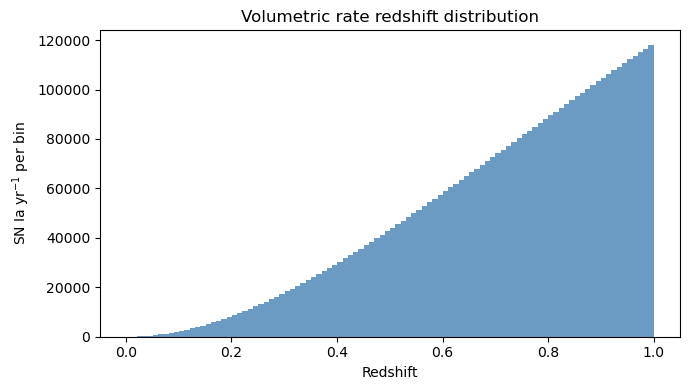

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — AsymmetricGaussian($\mu=0.973$, $\sigma_-=1.472$, $\sigma_+=0.222$)
- **c** — AsymmetricGaussian($\mu=-0.054$, $\sigma_-=0.043$, $\sigma_+=0.101$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.1$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

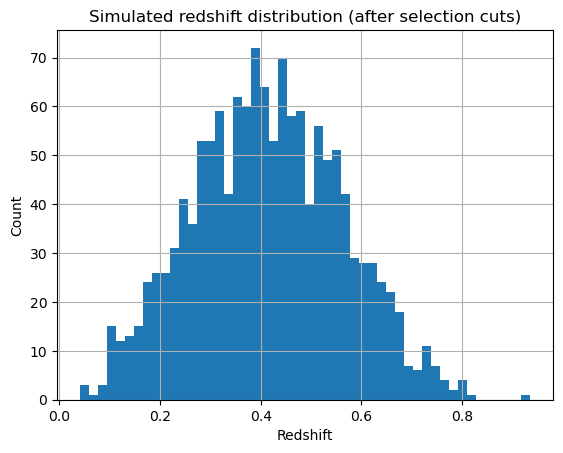

In [15]:
# redshift distribution of simulated SNe (post-cuts)
fig, ax = plt.subplots()
lightcurves_after_quality_cut["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution (after selection cuts)")
plt.show()

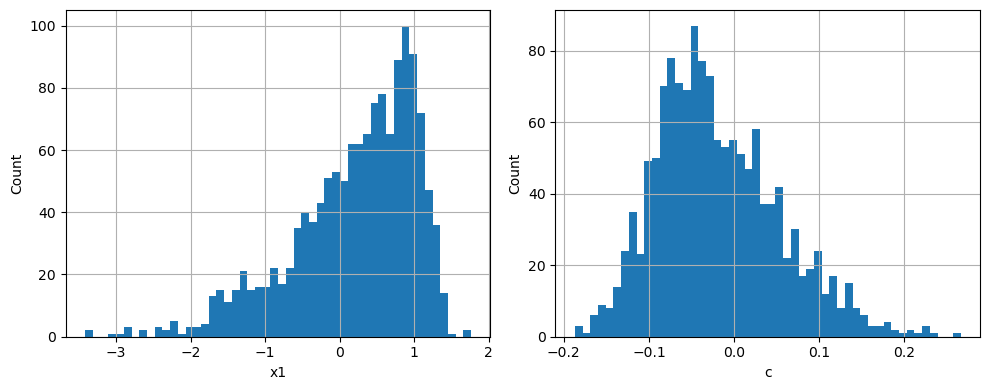

In [16]:
# x1 and c distributions (post-cuts)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
lightcurves_after_quality_cut["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
lightcurves_after_quality_cut["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

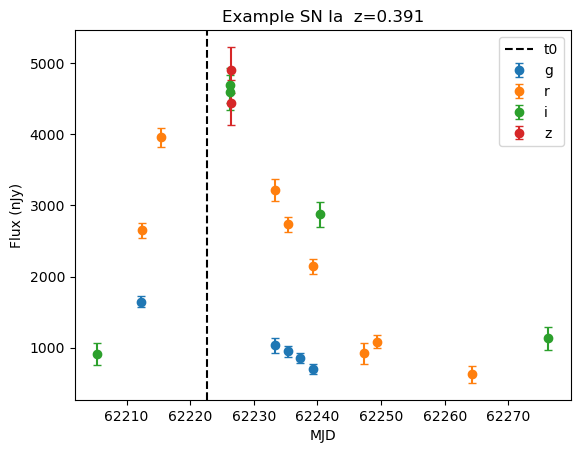

In [17]:
# example light curve for a single SN (post-cuts)
sn = lightcurves_after_quality_cut.iloc[np.random.choice(len(lightcurves_after_quality_cut))]
lc = sn["lightcurve"]
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"]) / (1.0 + sn["source_redshift"]) > -20
    mask &= (lc["mjd"] - sn["source_t0"]) / (1.0 + sn["source_redshift"]) < 100
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

## 11. Save Results

In [18]:
# output_dir = Path("output")
# output_dir.mkdir(exist_ok=True)

# # results.to_parquet(output_dir / "lsst_snia_v530_results.parquet")
# # print(f"Saved all simulated SNe to {output_dir / 'lsst_snia_v530_results.parquet'}")

# lightcurves_after_quality_cut.to_parquet(output_dir / "lsst_snia_v530_after_cuts.parquet")
# print(f"Saved post-cut SNe to {output_dir / 'lsst_snia_v530_after_cuts.parquet'}")